## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import numpy as np

import warnings
warnings.filterwarnings("ignore")

# CHANGE DATA PATH HERE -- INPUT IS KRISH'S CAR DATA, ALL OF IT
data_path = Path("C:/Users/adams/Desktop/data/CAR Data/df_main_cleaned.csv")

df_main = pd.read_csv(data_path, usecols=range(8))

# Identify all Contact Session IDs that ever had Intake Outdial EP
outdial_ids = df_main.loc[df_main["EP Name"] == "Intake Outdial EP", "Contact Session ID"].unique()

# Remove them
df_main = df_main[~df_main["Contact Session ID"].isin(outdial_ids)].copy()

## Week 5: Full New Method

In [2]:
# list of 11 relevant menus we want to tag calls to

menu_list = ["Main Number Telephony EP", "Legal Menu Telephony EP", "Pre-Legal Menu Seniors Menu Telephony EP", "Other Legal Menu Telephony EP", "Legal Housing Menu Telephony EP", "Legal Family Menu Telephony EP", "Farmworker Main Number Telephony EP", "Legal Benefits Menu Telephony EP", "Legal HIV Menu Telephony EP", "Legal Immigration Menu Telephony EP", "Legal Employment Menu Telephony EP"]

# --- Start building final dataframe ---
# Get unique Contact Session IDs
df_final = (df_main[["Contact Session ID"]].drop_duplicates().sort_values(by="Contact Session ID").reset_index(drop=True))

# --- Assign Menu = last EP Name in menu_list for each call ---
# Filter only rows with EP Names in menu_list
df_menus = df_main[df_main["EP Name"].isin(menu_list)].copy()

# Sort so that later rows come later; then take last EP Name per session
df_menus_sorted = df_menus.sort_values(by=["Contact Session ID", "Activity Start Timestamp"])

# Get last EP Name per session
last_menus = (df_menus_sorted.groupby("Contact Session ID")["EP Name"].last().reset_index().rename(columns={"EP Name": "Menu"}))

# Merge into final dataframe
df_final = df_final.merge(last_menus, on="Contact Session ID", how="left")

# --- Add placeholder Abandoned + Reason columns ---
df_final["Abandoned"] = ""
df_final["Reason"] = ""

In [3]:
# --- Reset any previous runs safely ---
for col in ["Last Activity Name", "Abandoned?", "Count"]:
    if col in df_final.columns:
        df_final = df_final.drop(columns=[col])

# --- Get the last Activity Name for each Contact Session ID ---
df_last_activity = (
    df_main
    .sort_values(["Contact Session ID", "Activity Start Timestamp"])
    .groupby("Contact Session ID")["Activity Name"]
    .last()
    .reset_index()
    .rename(columns={"Activity Name": "Last Activity Name"})
)

# Merge into df_final
df_final = df_final.merge(df_last_activity, on="Contact Session ID", how="left")

# --- Build summary table ---
df_summary = (
    df_final
    .groupby(["Menu", "Last Activity Name"])
    .size()
    .reset_index(name="Count")
    .sort_values(["Menu", "Count"], ascending=[True, False])
    .reset_index(drop=True)
)

# Add blank column for manual labeling
df_summary["Abandoned?"] = ""

# --- Show all rows ---
pd.set_option('display.max_rows', None)
df_summary

,Menu,Last Activity Name,Count,Abandoned?
0,Farmworker Main Number Telephony EP,FarmworkerMainMenu,9640,
1,Farmworker Main Number Telephony EP,LanguageSelectionMenu,156,
2,Farmworker Main Number Telephony EP,MigrantVoicemailTransfer,67,
3,Farmworker Main Number Telephony EP,DisconnectContact1,44,
4,Farmworker Main Number Telephony EP,ClosedMenu,29,
5,Farmworker Main Number Telephony EP,ClinicVoicemailTransfer,7,
6,Farmworker Main Number Telephony EP,StaffDirectorySpanishTransfer,5,
7,Farmworker Main Number Telephony EP,StaffDirectoryEnglishTransfer,3,
8,Farmworker Main Number Telephony EP,AddressFaxHoursMenu,1,
9,Legal Benefits Menu Telephony EP,ClosedQueueMenu,4674,


In [4]:
df_final['Menu'].value_counts()

Main Number Telephony EP                    120093
Legal Menu Telephony EP                      27715
Legal Family Menu Telephony EP               22753
Legal Housing Menu Telephony EP              16492
Pre-Legal Menu Seniors Menu Telephony EP     12944
Other Legal Menu Telephony EP                12204
Farmworker Main Number Telephony EP           9953
Legal Benefits Menu Telephony EP              7210
Legal Employment Menu Telephony EP            4564
Legal Immigration Menu Telephony EP           3516
Legal HIV Menu Telephony EP                   1603
Name: Menu, dtype: int64

In [5]:
# --- Identify calls missing a Last Activity Name ---
missing_ids = df_final.loc[df_final["Last Activity Name"].isna(), "Contact Session ID"].unique()

print("Number of calls with no last activity name:", len(missing_ids))

# --- Pull their df_main rows for inspection ---
def inspect_missing_last_activity(df_main, missing_ids):
    df_missing = df_main[df_main["Contact Session ID"].isin(missing_ids)].copy()

    # Preserve order of IDs
    df_missing["Contact Session ID"] = pd.Categorical(
        df_missing["Contact Session ID"],
        categories=missing_ids,
        ordered=True
    )

    return df_missing.sort_values(
        ["Contact Session ID", "Activity Start Timestamp"]
    ).reset_index(drop=True)

df_investigate = inspect_missing_last_activity(df_main, missing_ids)

df_investigate.head(4000)


Number of calls with no last activity name: 172


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,00906e65-550d-4190-9add-da5a8d3a452e,Main Number Telephony EP,NaN,NaN,2025-08-05 16:45:39,NaN,NaN,NaN
1,00906e65-550d-4190-9add-da5a8d3a452e,NaN,LACMain,NaN,2025-08-05 16:45:39,NaN,NaN,NaN
2,00906e65-550d-4190-9add-da5a8d3a452e,Main Number Telephony EP,NaN,NaN,2025-08-05 16:45:39,NaN,NaN,NO_ANSWER_FROM_CUSTOMER
3,04d7e372-6ff6-41b4-813e-bc18dd6dabfe,Main Number Telephony EP,NaN,NaN,2025-09-08 06:55:48,NaN,NaN,NaN
4,04d7e372-6ff6-41b4-813e-bc18dd6dabfe,NaN,LACMain,NaN,2025-09-08 06:55:48,NaN,NaN,NaN
5,04d7e372-6ff6-41b4-813e-bc18dd6dabfe,Main Number Telephony EP,NaN,NaN,2025-09-08 06:55:48,NaN,NaN,Customer Left
6,077fc423-c9e5-4429-a299-a9d37e23fdc8,Main Number Telephony EP,NaN,NaN,2025-01-12 07:17:33,NaN,NaN,NaN
7,077fc423-c9e5-4429-a299-a9d37e23fdc8,Main Number Telephony EP,NaN,NaN,2025-01-12 07:17:33,NaN,NaN,NaN
8,07ccff31-418a-4eac-b3f1-84aeac8339b0,Main Number Telephony EP,NaN,NaN,2025-08-23 07:13:39,NaN,NaN,NaN
9,07ccff31-418a-4eac-b3f1-84aeac8339b0,NaN,LACMain,NaN,2025-08-23 07:13:39,NaN,NaN,NaN


In [6]:
# Script for investigating the raw data from a specific subgroup!

# 1. Find the Contact Session IDs that match the criteria
family_ids = df_final.loc[
    (df_final["Menu"] == "Main Number Telephony EP") &
    (df_final["Last Activity Name"] == "AppointmentMenu"),
    "Contact Session ID"
].unique()

# 2. Pull ALL rows from df_main for these Contact Session IDs
test_subgroup = df_main[df_main["Contact Session ID"].isin(family_ids)].copy()

test_subgroup.head(200)

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
72597,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,NaN,2025-01-22 13:29:27,NaN,NaN,NaN
72598,51401a54-67ec-40d7-a8d0-288467e06c86,NaN,LACMain,NaN,2025-01-22 13:29:27,NaN,NaN,NaN
72599,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-01-22 13:29:27,NaN,NaN,NaN
72600,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,LACMain,NaN,2025-01-22 13:29:27,NaN,NaN,NaN
72610,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,MainMenu,2025-01-22 13:29:42,NaN,NaN,NaN
72621,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,HelpWithLegalorOtherReasonMenu,2025-01-22 13:30:38,NaN,NaN,NaN
72623,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,MainMenu,2025-01-22 13:30:48,NaN,NaN,NaN
72626,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,ComplimentOrComplaintMenu,2025-01-22 13:31:00,NaN,NaN,NaN
72631,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,MainMenu,2025-01-22 13:31:18,NaN,NaN,NaN
72632,51401a54-67ec-40d7-a8d0-288467e06c86,Main Number Telephony EP,NaN,AppointmentMenu,2025-01-22 13:31:20,NaN,NaN,NaN


# Week 4: Immigration and HIV Menus (Abandonment)

In [7]:
# CAR DATA – HIV
hiv_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalHIVMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL
df_sessions_hiv = hiv_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions_hiv['Abandoned'] = 'Unknown'
df_sessions_hiv['Reason'] = ''

# CAR DATA – Immigration
imm_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalImmigrationMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL
df_sessions_imm = imm_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions_imm['Abandoned'] = 'Unknown'
df_sessions_imm['Reason'] = ''

# CAR DATA - EMPLOYMENT
employ_df = (
    df_main
    .groupby('Contact Session ID')
    .filter(lambda x: (x['Flow Name'] == 'LegalEmploymentMenu').any())
    .sort_values(by=['Contact Session ID', 'Activity Start Timestamp'])
    .reset_index(drop=True)
)

# NEW DATASET, ONE ROW = ONE CALL (unique Contact Session ID)
df_sessions = employ_df[['Contact Session ID']].drop_duplicates().copy()
df_sessions['Abandoned'] = 'Unknown'
df_sessions['Reason'] = ''

In [8]:
# Return the remaining untagged (Abandoned == 'Unknown') sessions along with the corresponding activity rows from the menu dataframe.
def get_remaining_untagged_random(df_sessions, menu_df):
    remaining_ids = df_sessions.loc[df_sessions['Abandoned'] == 'Unknown', 'Contact Session ID'].unique()
    np.random.shuffle(remaining_ids)
    remaining_df = menu_df[menu_df['Contact Session ID'].isin(remaining_ids)].copy()
    remaining_df['Contact Session ID'] = pd.Categorical(remaining_df['Contact Session ID'], categories=remaining_ids, ordered=True)
    return remaining_df.sort_values(['Contact Session ID', 'Activity Start Timestamp']).reset_index(drop=True)


In [9]:
get_remaining_untagged_random(df_sessions_imm, imm_df).head(40)

,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
0,649ec9ff-f127-4c50-ae02-e76da65c744f,Main Number Telephony EP,NaN,NaN,2025-05-01 08:56:29,NaN,NaN,NaN
1,649ec9ff-f127-4c50-ae02-e76da65c744f,NaN,LACMain,NaN,2025-05-01 08:56:29,NaN,NaN,NaN
2,649ec9ff-f127-4c50-ae02-e76da65c744f,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-05-01 08:56:29,NaN,NaN,NaN
3,649ec9ff-f127-4c50-ae02-e76da65c744f,Main Number Telephony EP,LACMain,NaN,2025-05-01 08:56:29,NaN,NaN,NaN
4,649ec9ff-f127-4c50-ae02-e76da65c744f,Main Number Telephony EP,NaN,MainMenu,2025-05-01 08:56:38,NaN,NaN,NaN
5,649ec9ff-f127-4c50-ae02-e76da65c744f,NaN,PreLegalMenuSeniorsMenu,NaN,2025-05-01 08:57:08,NaN,NaN,NaN
6,649ec9ff-f127-4c50-ae02-e76da65c744f,Pre-Legal Menu Seniors Menu Telephony EP,NaN,SeniorsMenu,2025-05-01 08:57:08,NaN,NaN,NaN
7,649ec9ff-f127-4c50-ae02-e76da65c744f,NaN,LegalMenu,NaN,2025-05-01 08:57:19,NaN,NaN,NaN
8,649ec9ff-f127-4c50-ae02-e76da65c744f,Legal Menu Telephony EP,NaN,LegalMenu1,2025-05-01 08:57:19,NaN,NaN,NaN
9,649ec9ff-f127-4c50-ae02-e76da65c744f,Legal Menu Telephony EP,NaN,LegalMenu2,2025-05-01 08:58:09,NaN,NaN,NaN


In [10]:
# -----------------------------
# Rule Engine Helper Functions
# -----------------------------
def mark_not_abandoned(df_sessions, df, column, values, reason):
    if isinstance(values,str): values=[values]
    ids=df.loc[df[column].isin(values),'Contact Session ID'].unique()
    df_sessions.loc[df_sessions['Contact Session ID'].isin(ids)&(df_sessions['Abandoned']=='Unknown'),['Abandoned','Reason']]=['Not Abandoned',reason]

def mark_not_abandoned_position(df_sessions, df, column, values, reason, position=-1, final_value='Not Abandoned'):
    if isinstance(values,str): values=[values]
    ids=[]
    for sid,g in df.sort_values(['Contact Session ID','Activity Start Timestamp']).groupby('Contact Session ID'):
        g=g.reset_index(drop=True)
        if len(g)<abs(position): continue
        if g.iloc[position][column] in values: ids.append(sid)
    df_sessions.loc[df_sessions['Contact Session ID'].isin(ids)&(df_sessions['Abandoned']=='Unknown'),['Abandoned','Reason']]=[final_value,reason]

def mark_not_abandoned_last_row_queue(df_sessions, df, queue_name, reason): mark_not_abandoned_position(df_sessions,df,'Queue Name',queue_name,reason,position=-1,final_value='Not Abandoned')

def mark_not_abandoned_nth_last_activity(df_sessions, df, activities, reason, position=-2): mark_not_abandoned_position(df_sessions,df,'Activity Name',activities,reason,position=position,final_value='Not Abandoned')

def mark_abandoned(df_sessions, df, column, values, reason): 
    if isinstance(values,str): values=[values]
    ids=df.loc[df[column].isin(values),'Contact Session ID'].unique()
    df_sessions.loc[df_sessions['Contact Session ID'].isin(ids)&(df_sessions['Abandoned']=='Unknown'),['Abandoned','Reason']]=['Abandoned',reason]

def mark_abandoned_last_row(df_sessions, df, column, values, reason): mark_not_abandoned_position(df_sessions,df,column,values,reason,position=-1,final_value='Abandoned')

def mark_abandoned_second_last(df_sessions, df, column, values, reason): mark_not_abandoned_position(df_sessions,df,column,values,reason,position=-2,final_value='Abandoned')

In [11]:
# EMPLOYMENT NOT ABANDONED
mark_not_abandoned(df_sessions,employ_df,'Activity Name','LegalServerScreenPop','Callback')
mark_not_abandoned(df_sessions,employ_df,'Activity Name','ClosedQueueMenu','Closed Queue')
mark_not_abandoned_position(df_sessions,employ_df,'EP Name',['Closed Hours-Holidays Menu Telephony EP'],'Closed Hours')
mark_not_abandoned(df_sessions,employ_df,'Queue Name','Front Desk Transfer','Front Desk Transfer')
mark_not_abandoned_position(df_sessions,employ_df,'EP Name',['Legal Menu Telephony EP','Other Legal Menu Telephony EP','Legal Housing Menu Telephony EP','Legal Immigration Menu Telephony EP','Main Number Telephony EP'],'Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_position(df_sessions,employ_df,'EP Name','Legal Menu Telephony EP','Different Menu',position=-2,final_value="Doesn't Apply")

# EMPLOYMENT ABANDONED
mark_abandoned_second_last(df_sessions,employ_df,'Activity Name','IntakePreQueueMessage1','Left PreQueue Message')
mark_abandoned(df_sessions,employ_df,'EP Name','Legal Employment Menu Telephony EP','Customer Left Employment Menu')
mark_abandoned_last_row(df_sessions,employ_df,'Queue Name','Employment','Customer Left Employment Queue')
mark_abandoned_last_row(df_sessions,employ_df,'Queue Name','Employment SP','Customer Left Employment Queue')

# HIV NOT ABANDONED
mark_not_abandoned(df_sessions_hiv,hiv_df,'Activity Name','LegalServerScreenPop','Callback')
mark_not_abandoned(df_sessions_hiv,hiv_df,'Activity Name','ClosedQueueMenu','Closed Queue')
mark_not_abandoned_position(df_sessions_hiv,hiv_df,'EP Name',['Closed Hours-Holidays Menu Telephony EP'],'Closed Hours')
mark_not_abandoned(df_sessions_hiv,hiv_df,'Queue Name','Front Desk Transfer','Front Desk Transfer')
mark_not_abandoned_position(df_sessions_hiv,hiv_df,'EP Name',['Legal Benefits Menu Telephony EP','Legal Housing Menu Telephony EP','Legal Immigration Menu Telephony EP','Main Number Telephony EP','LegalMenu2','Other Legal Menu'],'Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_last_row_queue(df_sessions_hiv,hiv_df,'HIV Voicemail Transfer','Heard Voicemail')
mark_not_abandoned_position(df_sessions_hiv,hiv_df,'EP Name',['All LAC Queues Telephony EP','Legal Family Menu Telephony EP','Legal Menu Telephony EP','Other Legal Menu Telephony EP'],'Different Menu',position=-1,final_value="Doesn't Apply")

# HIV ABANDONED
mark_abandoned_last_row(df_sessions_hiv,hiv_df,'Activity Name','HIVMenu','Left HIV Menu')
mark_abandoned_second_last(df_sessions_hiv,hiv_df,'Activity Name','HIVMenu','Left HIV Menu')
mark_abandoned_second_last(df_sessions_hiv,hiv_df,'Flow Name','LegalHIVMenu','Left HIV Menu')

# IMMIGRATION NOT ABANDONED
mark_not_abandoned(df_sessions_imm,imm_df,'Activity Name','LegalServerScreenPop','Callback')
mark_not_abandoned(df_sessions_imm,imm_df,'Activity Name','ClosedQueueMenu','Closed Queue')
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name',['Closed Hours-Holidays Menu Telephony EP'],'Closed Hours')
mark_not_abandoned(df_sessions_imm,imm_df,'Queue Name','Front Desk Transfer','Front Desk Transfer')
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name',['Legal HIV Menu Telephony EP', 'Legal Employment Menu Telephony EP', 'Legal Menu Telephony EP','Other Legal Menu Telephony EP','Legal Housing Menu Telephony EP','Main Number Telephony EP'],'Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_last_row_queue(df_sessions_imm,imm_df,'Trafficking Voicemail Transfer','Heard Voicemail')
mark_not_abandoned_nth_last_activity(df_sessions_imm,imm_df,'IntakePreQueueMessage1','Reached Intake',position=-3)
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name','Pre-Legal Menu Seniors Menu Telephony EP','Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name','Legal Family Menu Telephony EP','Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name','Courtesy Callback Telephony EP','Callback')
mark_not_abandoned_position(df_sessions_imm,imm_df,'EP Name','Legal Benefits Menu Telephony EP','Different Menu',position=-1,final_value="Doesn't Apply")
mark_not_abandoned_nth_last_activity(df_sessions_imm, imm_df, 'IntakePreQueueMessage1', 'Reached Intake', position=-2)

# IMMIGRATION ABANDONED
mark_abandoned_second_last(df_sessions_imm,imm_df,'Activity Name','QueueMenu1','Left Queue')
mark_abandoned_second_last(df_sessions_imm,imm_df,'Activity Name',['ImmigrationMenu','ImmigrationOtherMenu'],'Left Immigration Menu')
mark_abandoned_second_last(df_sessions_imm,imm_df,'Flow Name','LegalImmigrationMenu','Left Immigration Menu')
mark_abandoned_second_last(df_sessions_imm,imm_df,'Activity Name','PlayMOH300s','Left Queue')
mark_abandoned_last_row(df_sessions_imm,imm_df,'Activity Name','ImmigrationMenu','Left Immigration Menu')
mark_abandoned_last_row(df_sessions_imm, imm_df, 'Activity Name', 'QueueMenu1', 'Left Queue')
mark_abandoned_last_row(df_sessions_imm, imm_df, 'Activity Name', 'PlayMOH300s', 'Left Queue')




## HIV Results

In [12]:
# HIV RESULTS
df_sessions_hiv.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Left HIV Menu,756
1,Doesn't Apply,Different Menu,234
5,Not Abandoned,Heard Voicemail,836
3,Not Abandoned,Closed Queue,252
2,Not Abandoned,Callback,23
4,Not Abandoned,Front Desk Transfer,6


In [13]:
# Summary table
summary_hiv = df_sessions_hiv['Abandoned'].value_counts(dropna=False).reset_index()
summary_hiv.columns = ['Abandoned', 'Count']
summary_hiv['Percent'] = (summary_hiv['Count'] / summary_hiv['Count'].sum() * 100).round(2)
summary_hiv = summary_hiv.sort_values(by='Abandoned')
summary_hiv

,Abandoned,Count,Percent
1,Abandoned,756,35.88
2,Doesn't Apply,234,11.11
0,Not Abandoned,1117,53.01


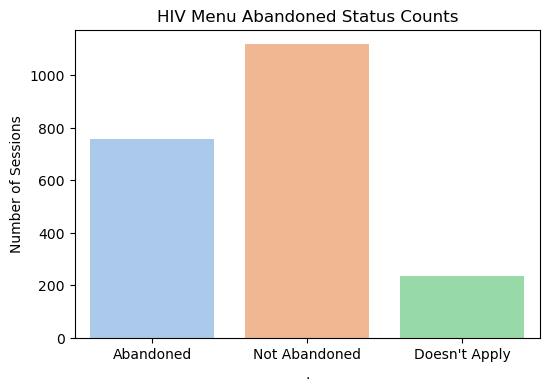

In [14]:
# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions_hiv, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('HIV Menu Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

## Immigration Results

In [15]:
# IMMIGRATION RESULTS
df_sessions_imm.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Left Immigration Menu,640
1,Abandoned,Left Queue,39
2,Doesn't Apply,Different Menu,80
5,Not Abandoned,Closed Queue,2530
3,Not Abandoned,Callback,184
7,Not Abandoned,Heard Voicemail,139
8,Not Abandoned,Reached Intake,18
4,Not Abandoned,Closed Hours,2
6,Not Abandoned,Front Desk Transfer,2


In [16]:
# Summary table
summary_imm = df_sessions_imm['Abandoned'].value_counts(dropna=False).reset_index()
summary_imm.columns = ['Abandoned', 'Count']
summary_imm['Percent'] = (summary_imm['Count'] / summary_imm['Count'].sum() * 100).round(2)
summary_imm = summary_imm.sort_values(by='Abandoned')
summary_imm

,Abandoned,Count,Percent
1,Abandoned,679,18.68
2,Doesn't Apply,80,2.20
0,Not Abandoned,2875,79.11


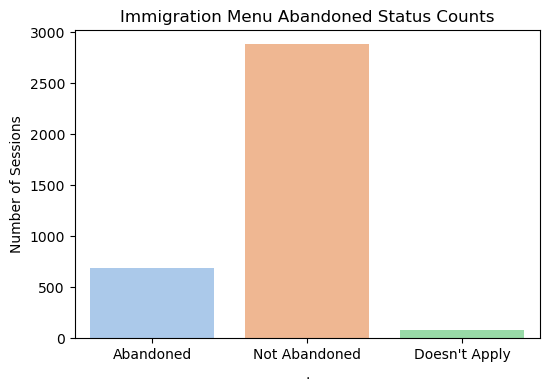

In [17]:
# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions_imm, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('Immigration Menu Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

##  Employment Results

In [18]:
df_sessions.groupby(['Abandoned', 'Reason']).size().reset_index(name='count').sort_values(
    by=['Abandoned', 'count'], ascending=[True, False]
)

,Abandoned,Reason,count
0,Abandoned,Customer Left Employment Menu,280
1,Abandoned,Left PreQueue Message,17
2,Doesn't Apply,Different Menu,94
5,Not Abandoned,Closed Queue,3781
3,Not Abandoned,Callback,538
4,Not Abandoned,Closed Hours,2
6,Not Abandoned,Front Desk Transfer,2


In [19]:
summary = df_sessions['Abandoned'].value_counts(dropna=False).reset_index()
summary.columns = ['Abandoned', 'Count']
summary['Percent'] = (summary['Count'] / summary['Count'].sum() * 100).round(2)
summary = summary.sort_values(by='Abandoned')  # sort alphabetically by Abandoned
summary

,Abandoned,Count,Percent
1,Abandoned,297,6.30
2,Doesn't Apply,94,1.99
0,Not Abandoned,4323,91.71


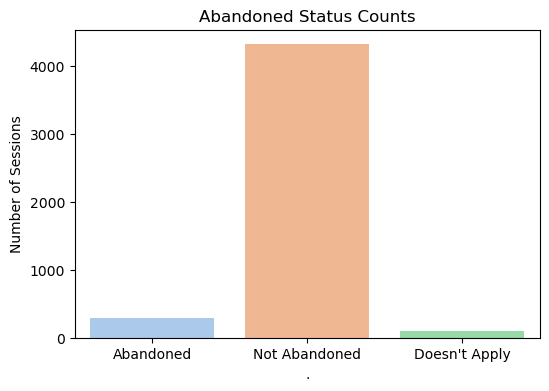

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_sessions, x='Abandoned', order=['Abandoned', 'Not Abandoned', "Doesn't Apply"], palette='pastel')
plt.title('Abandoned Status Counts')
plt.ylabel('Number of Sessions')
plt.xlabel('.')
plt.show()

## Verbiage Analysis 1: Voicemail vs. Not Voicemail (Week 2)

In [21]:
# OBJECTIVE: Determine, of all calls, how many lead to the clinic voicemail as opposed to anything other than a voicemail
# REASON: Gain additional information on whether it may be worthy to put option 4 (leads to a voicemail) before option 3 (does not lead to a voicemail)

# Get the final (latest) row for each Contact Session ID
df_last = (
    df_main.sort_values('Activity Start Timestamp')
           .groupby('Contact Session ID', as_index=False)
           .last()
)

# Check how many have missing Queue Name
missing_queue = df_last['Queue Name'].isna().sum()
print(f"Number of calls with missing final Queue Name: {missing_queue}")

# Exclude those missing values ---
df_last_valid = df_last.dropna(subset=['Queue Name'])

# Create flags for voicemail vs other ---
df_last_valid['Call Type'] = df_last_valid['Queue Name'].apply(
    lambda x: 'Voicemail' if x == 'Clinic Voicemail Transfer' else 'Other'
)

# Count totals and proportions ---
call_counts = df_last_valid['Call Type'].value_counts()
call_proportions = df_last_valid['Call Type'].value_counts(normalize=True) * 100

print("\n--- Call Counts ---")
print(call_counts)

print("\n--- Call Proportions (%) ---")
print(call_proportions.round(2))

# See top non-voicemail destinations ---
top_queues = (
    df_last_valid[df_last_valid['Call Type'] == 'Other']['Queue Name']
    .value_counts()
    .head(20)
)
print("\n--- Top 10 Non-Voicemail Queue Names ---")
print(top_queues)

Number of calls with missing final Queue Name: 148100

--- Call Counts ---
Other        65226
Voicemail    25721
Name: Call Type, dtype: int64

--- Call Proportions (%) ---
Other        71.72
Voicemail    28.28
Name: Call Type, dtype: float64

--- Top 10 Non-Voicemail Queue Names ---
Staff Directory English Transfer       28035
Front Desk Transfer                    17442
Staff Directory Spanish Transfer        3958
Criminal Records Voicemail Transfer     2267
Family                                  1945
Consumer                                1454
SubSenior Other                         1188
Housing                                 1059
HIV Voicemail Transfer                   836
Benefits                                 789
SubSenior Tenant                         684
SubSenior Benefits                       683
Employment                               514
SubSenior Consumer                       508
SubSenior Family                         482
SubSenior Homeowner                     

In [22]:
# Investigate cause of all the unknown final queues

missing_queues_sessions = df_last[df_last['Queue Name'].isna()]['Contact Session ID']
termination_summary = (
    df_main[df_main['Contact Session ID'].isin(missing_queues_sessions)]
    ['Termination Reason']
    .value_counts()
)
print(termination_summary)

Customer Left                      53124
System disconnected the contact     4824
NO_ANSWER_FROM_CUSTOMER              391
System Error                         157
Name: Termination Reason, dtype: int64


## Verbiage Analysis 2: Complaint/Compliment Menu (Week 2)

In [23]:
# OBJECTIVE: Determine how many calls reached compliment/complaint menu, and how many of these actually used an agent's time
# FIRST ATTEMPT: Flawed (look at following code for my final and better analysis)

# Filter to calls from March 16, 2025 onward
df_filtered = df_main[df_main['Activity Start Timestamp'] >= '2025-03-16']

# Find all calls that reached the Compliment or Complaint menu
complaint_calls = df_filtered[df_filtered['Activity Name'] == 'ComplimentOrComplaintMenu']

# Get unique Contact Session IDs for those calls
complaint_call_ids = complaint_calls['Contact Session ID'].unique()

# Subset full dataset to just those sessions
subset = df_filtered[df_filtered['Contact Session ID'].isin(complaint_call_ids)]

# Group by Contact Session ID and see which sessions ever had an Agent Name
grouped = subset.groupby('Contact Session ID')['Agent Name'].apply(lambda x: x.notna().any())

# Results
num_total = len(grouped)
num_with_agent = grouped.sum()
num_without_agent = num_total - num_with_agent

print(f"Total calls that reached Compliment/Complaint Menu: {num_total}")
print(f"Calls where an Agent Name appeared (spoke to agent): {num_with_agent}")
print(f"Calls where no Agent Name appeared (likely voicemail/no agent): {num_without_agent}")

# Optional: percentage
print(f"Percent that reached an agent: {num_with_agent / num_total * 100:.2f}%")

subset.head(160)

Total calls that reached Compliment/Complaint Menu: 353
Calls where an Agent Name appeared (spoke to agent): 171
Calls where no Agent Name appeared (likely voicemail/no agent): 182
Percent that reached an agent: 48.44%


,Contact Session ID,EP Name,Flow Name,Activity Name,Activity Start Timestamp,Queue Name,Agent Name,Termination Reason
2088449,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088450,d474178a-c0ac-475d-8b13-3340a5211c00,NaN,LACMain,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088451,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,LanguageSelectionMenu,2025-03-18 10:36:37,NaN,NaN,NaN
2088452,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,LACMain,NaN,2025-03-18 10:36:37,NaN,NaN,NaN
2088453,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,MainMenu,2025-03-18 10:36:45,NaN,NaN,NaN
2088465,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,ComplimentOrComplaintMenu,2025-03-18 10:37:41,NaN,NaN,NaN
2088466,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,MainMenu,2025-03-18 10:37:42,NaN,NaN,NaN
2088493,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,HelpWithLegalorOtherReasonMenu,2025-03-18 10:38:35,NaN,NaN,NaN
2088496,d474178a-c0ac-475d-8b13-3340a5211c00,Main Number Telephony EP,NaN,FrontDeskTransfer2,2025-03-18 10:38:44,NaN,NaN,NaN
2088497,d474178a-c0ac-475d-8b13-3340a5211c00,NaN,NaN,NaN,2025-03-18 10:38:44,Front Desk Transfer,NaN,NaN


In [24]:
import pandas as pd

# 1. Filter to March 16, 2025 onwards
df_filtered = df_main[df_main['Activity Start Timestamp'] >= '2025-03-16'].copy()

# Make sure timestamps are in datetime format
df_filtered['Activity Start Timestamp'] = pd.to_datetime(df_filtered['Activity Start Timestamp'])

# 2. Sort by session and timestamp to maintain order
df_filtered = df_filtered.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# 3. Find all Compliment/Complaint menu entries
complaint_entries = df_filtered[df_filtered['Activity Name'] == 'ComplimentOrComplaintMenu']

valid_sessions = []

# 4. For each such session, check if MainMenu appears within 60 seconds *after* Compliment/Complaint
for session_id, group in df_filtered.groupby('Contact Session ID'):
    complaint_times = group.loc[group['Activity Name'] == 'ComplimentOrComplaintMenu', 'Activity Start Timestamp']
    if complaint_times.empty:
        continue

    # For each time they entered the Compliment/Complaint menu
    backed_out = False
    for t in complaint_times:
        # Find any 'MainMenu' activity within 60 seconds *after* this timestamp
        back_to_main = group[
            (group['Activity Name'] == 'MainMenu') &
            (group['Activity Start Timestamp'] > t) &
            (group['Activity Start Timestamp'] <= t + pd.Timedelta(seconds=60))
        ]
        if not back_to_main.empty:
            backed_out = True
            break

    # Keep only those who did NOT go back to main within 1 minute
    if not backed_out:
        valid_sessions.append(session_id)

# 5. Subset to those sessions
subset = df_filtered[df_filtered['Contact Session ID'].isin(valid_sessions)]

# 6. Check whether they ever had an agent
grouped = subset.groupby('Contact Session ID')['Agent Name'].apply(lambda x: x.notna().any())

# 7. Summaries
num_total = len(grouped)
num_with_agent = grouped.sum()
num_without_agent = num_total - num_with_agent

print(f"Total sessions that stayed in Compliment/Complaint (did not return to Main Menu): {num_total}")
print(f"Sessions with an Agent Name (spoke to agent): {num_with_agent}")
print(f"Sessions without an Agent Name (likely voicemail): {num_without_agent}")
print(f"Percent that reached an agent: {num_with_agent / num_total * 100:.2f}%")

Total sessions that stayed in Compliment/Complaint (did not return to Main Menu): 114
Sessions with an Agent Name (spoke to agent): 84
Sessions without an Agent Name (likely voicemail): 30
Percent that reached an agent: 73.68%


In [25]:
# Create a dataframe of only the calls that passed the filter
survivor_data = df_filtered[df_filtered['Contact Session ID'].isin(valid_sessions)].copy()

# Sort by session and time for readability
survivor_data = survivor_data.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Display the first few rows neatly
print("Sample of surviving compliment/complaint sessions:")
display_cols = [
    'Contact Session ID',
    'Activity Start Timestamp',
    'Activity Name',
    'Queue Name',
    'Agent Name',
    'Termination Reason'
]

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(survivor_data[display_cols])


Sample of surviving compliment/complaint sessions:


,Contact Session ID,Activity Start Timestamp,Activity Name,Queue Name,Agent Name,Termination Reason
2098846,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098847,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098848,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,LanguageSelectionMenu,NaN,NaN,NaN
2098850,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:22,NaN,NaN,NaN,NaN
2098851,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:30:29,MainMenu,NaN,NaN,NaN
2098874,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:22,ComplimentOrComplaintMenu,NaN,NaN,NaN
2098882,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,FrontDeskTransfer2,NaN,NaN,NaN
2098883,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,NaN,Front Desk Transfer,NaN,NaN
2098884,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:45,NaN,NaN,NaN,NaN
2098885,00b976b5-8d07-4e0e-9fe8-dfb1ef8c0a68,2025-03-19 11:31:46,NaN,Front Desk Transfer,CBT Agent,NaN
